In [1]:
import numpy as np
import pandas as pd
from Python_Scripts.ST import *
import Python_Scripts.QuantBacktester as qd
import Python_Scripts.mass as mk
import Python_Scripts.tsa as tsa
import Python_Scripts.arma as arma
import matplotlib.pyplot as plt
import datetime
from arch import arch_model
from scipy.stats import t
from scipy import stats

In [2]:
excelReaderfObj = qd.ExcelInputReader()
priceFilePath = r'D:\Linear Model\data\Universe\INDTradingDays.xlsx'
closeDf = excelReaderfObj.getDataFrame(priceFilePath, sheetName='Close')
closeDf.set_index('Date', inplace=True)
closeDf = closeDf[['.NSEI']]
universeFilePath = r'D:\Linear Model\data\Universe\TradingDays.xlsx'
allTradingDatesDf = excelReaderfObj.getTradingDatesDataFrame(excelFile=universeFilePath, sheetName='Sheet1',
                                                             startDate=closeDf.first_valid_index())
allTradingDatesDf.reset_index(drop=True, inplace=True)
monthEndDatesDf = allTradingDatesDf.loc[allTradingDatesDf.groupby('YearMonth').Date.idxmax()]
monthEndDatesDf.sort_values(by=['Date'], inplace=True)
mergeObj = qd.Merger()
closeMergedDf = mergeObj.getMergedBymethodDf(allTradingDatesDf, closeDf)

In [3]:
rebalDates = ['2021-10-29',
              '2021-11-30',
              '2021-12-31',
              '2022-01-31',
              '2022-02-28',
              '2022-03-31',
              '2022-04-29',
              '2022-05-31',
              '2022-06-30',
              '2022-07-29',
              '2022-08-30',
              '2022-09-30',
              ]
rebalDates = ['2024-10-18']

resultDf = pd.DataFrame(columns=['Ret_Avg', 'Std_Avg', 'Avg_Ret', 'Avg_Std'], index=rebalDates)
resultDf14 = pd.DataFrame(columns=['Ret_Avg', 'Std_Avg', 'Avg_Ret', 'Avg_Std'], index=rebalDates)
stDf = pd.DataFrame(index=rebalDates, columns=['12', '14'])

In [4]:
i = 0

rebalDate = rebalDates[i]

wSize = [45, 60, 90, 100]

sim = mk.Match(closeMergedDf, rebalDate, windowSize=wSize[0], threshold=0.85)
reg = sim.getRegime()

print(reg)
print(rebalDate)

indexLists = [1, 2,3,4]

    idx      start        end        dp
0  5555 2018-02-20 2018-04-27  3.207108
1  5556 2018-02-21 2018-04-30  3.590996
2  5554 2018-02-19 2018-04-26  3.599230
3  2310 2005-01-24 2005-03-30  3.825316
4  2309 2005-01-20 2005-03-29  3.846647
2024-10-18


1
2
3
4


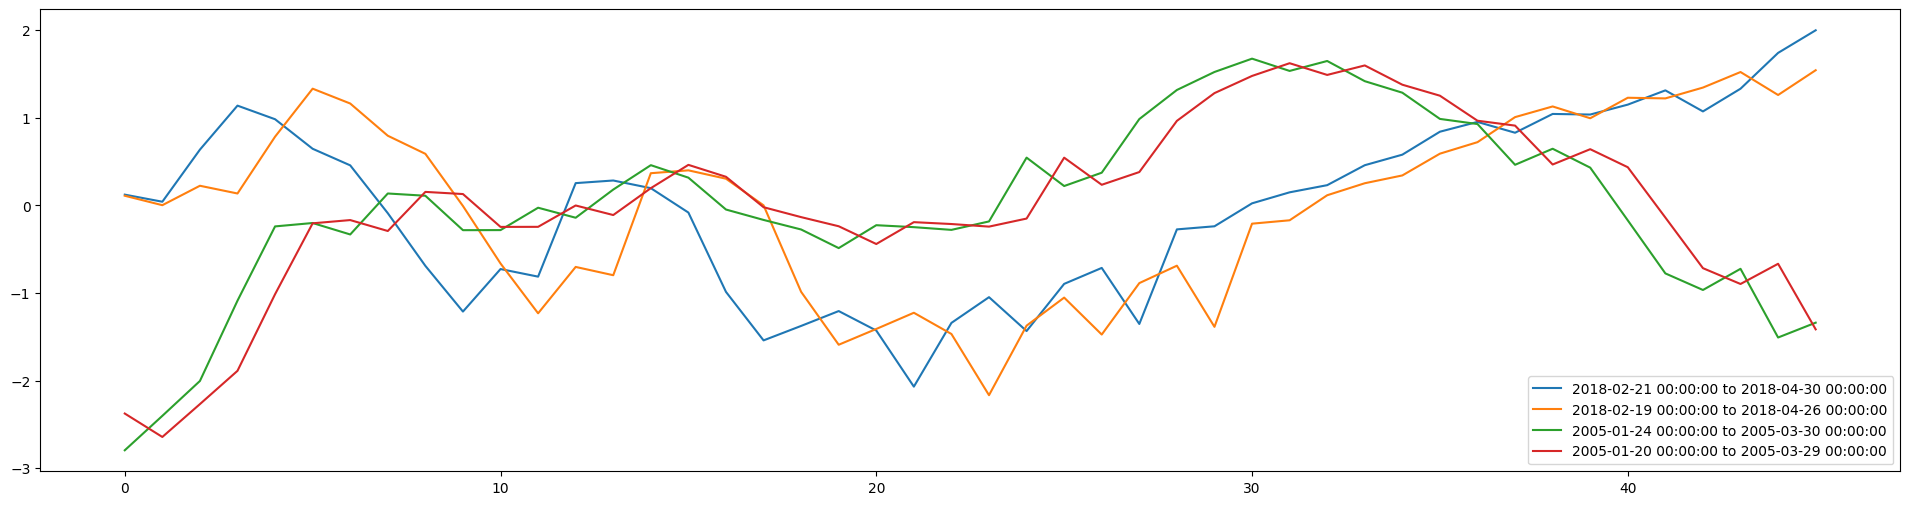

In [5]:
plt.figure(figsize=(24, 6))
ax = plt.gca()
# sim.plotMatch(ax)
for i in indexLists:
    ax.plot(stats.zscore(closeMergedDf.loc[reg.iloc[i].start: reg.iloc[i].end].values),
            label='{} to {}'.format(str(reg.iloc[i].start), str(reg.iloc[i].end)))

    print(i)
# ax.plot(stats.zscore(closeMergedDf.loc[reg.iloc[0].start: reg.iloc[0].end].values), color='k', lw=4, label='Query')
ax.legend()

               .NSEI
Date                
2018-04-05  10325.15
2018-04-06  10331.60
2018-04-09  10379.35
2018-04-10  10402.25
2018-04-11  10417.15
...              ...
2018-08-27  11691.95
2018-08-28  11738.50
2018-08-29  11691.90
2018-08-30  11676.80
2018-08-31  11680.50

[104 rows x 1 columns]
0.7


<Axes: >

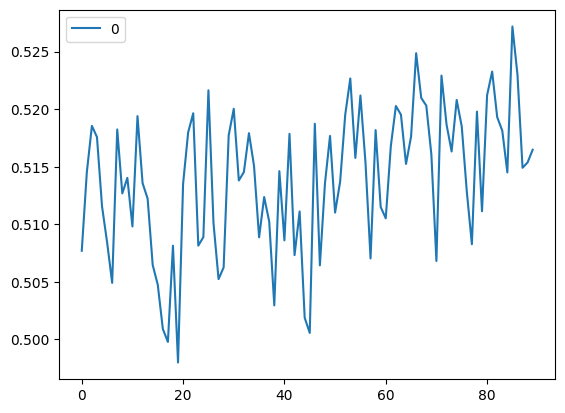

In [6]:
qReg = tsa.Preprocess(closeMergedDf, start=reg.start.iloc[indexLists[1]], end=reg.end.iloc[indexLists[1]]).getProcessedData()
qRegRet = tsa.Returns(qReg).getLogReturns()

qRoi = tsa.Preprocess(closeMergedDf, start=reg.end.iloc[indexLists[1]] - datetime.timedelta(21),).getProcessedData()[:90+14]
print(qRoi)
frCoff = tsa.FractionEstimate(np.log(qRoi), numLag=14, interval=0.1, confidence=0.95, tolerance=1e-4).getBest()
print(frCoff)
qFD = tsa.FractionalDifferencing(numLag=14, fraction= frCoff, tolerance=1e-4)
qFR = qFD.getDifferencedSeries(np.log(qRoi))
qFR.plot()

In [7]:
qFR12 = qFR[:45]
qFR14 = qFR[:90]

oRoi = closeMergedDf.loc[:rebalDate][-15:]
oFD = tsa.FractionalDifferencing(numLag=14, fraction= frCoff, tolerance=1e-4)
oFR = oFD.getDifferencedSeries(np.log(oRoi))

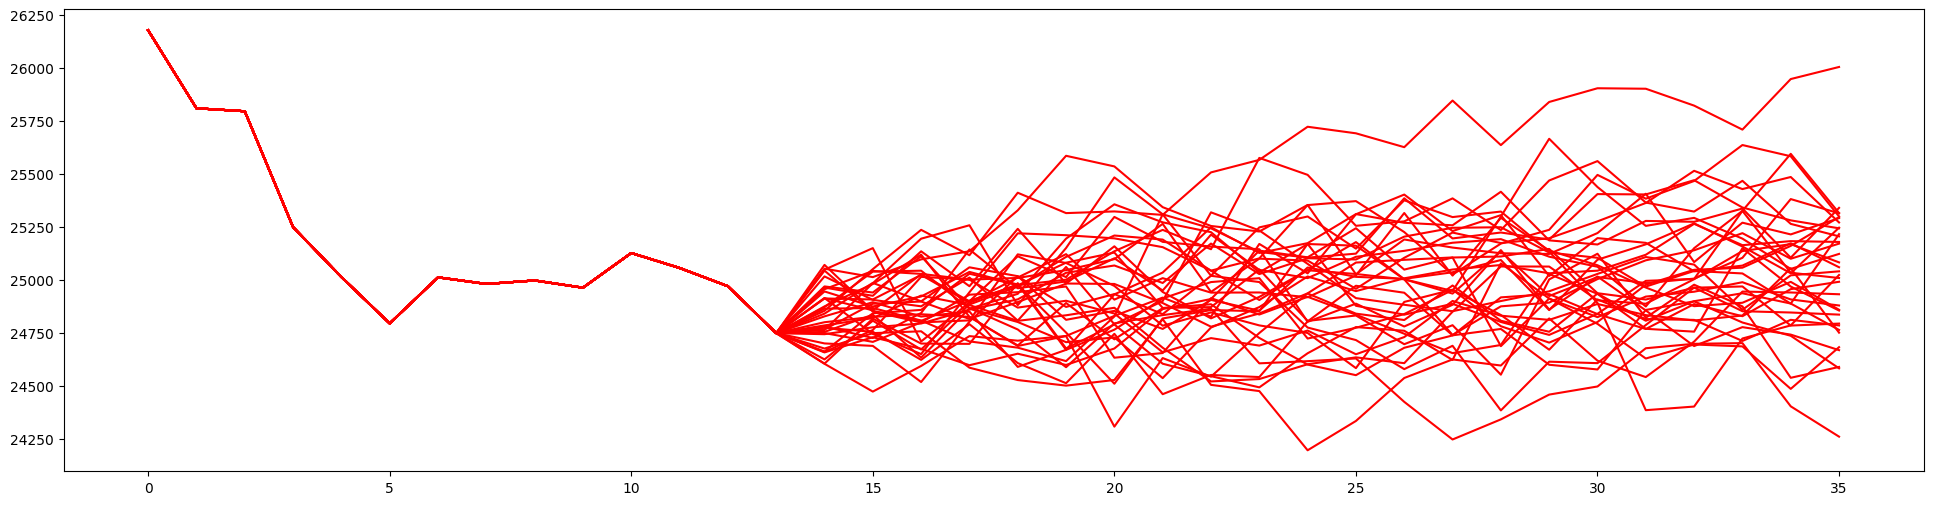

In [8]:
rep = 35

# ---- 2 month ---------------

qFR12IC = arma.ModelSelection(qFR12.values.flatten(), 5, 5).getICseries()

qFR12IC.sort_values("BIC").head()
mod12 = arma.Model(qFR12, p = 0, q = 0)
# mod12 = arma.Model(qFR12, p = 1, q = 0)
mod12.getParams()
sims12 = arma.SimulateFD(mod12, init_Val=oFR.iloc[0].values.flatten(), repetition=rep).getFDValues()
fig, ax = plt.subplots(figsize=(24, 6))
simPrice= []
for i in range(rep):
    simPrice.append(tsa.BackOperation(oRoi.values.flatten(), sims12.iloc[:, i], fraction= frCoff).getPrediction().values.flatten())
pd.DataFrame(simPrice).T.plot(ax=ax, color='r')
ax.get_legend().remove()

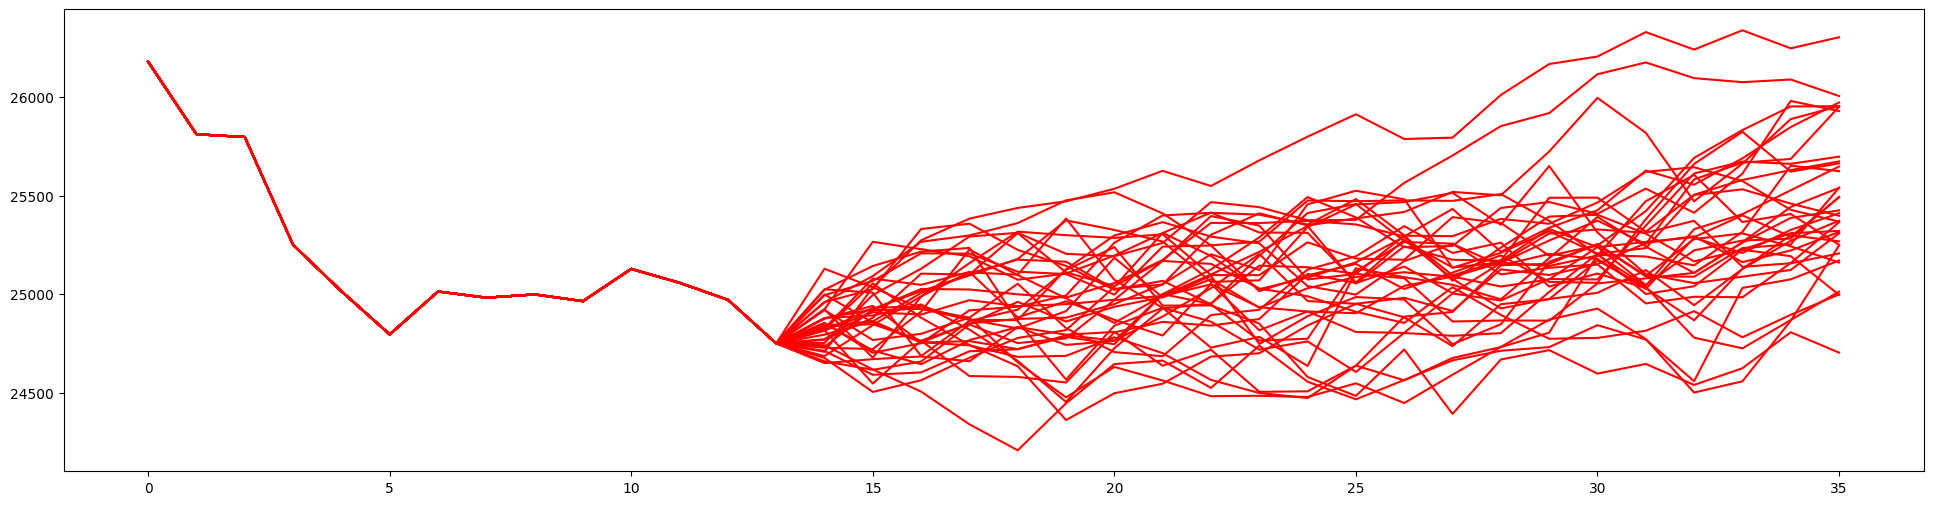

In [9]:
qFR14IC = arma.ModelSelection(qFR14.values.flatten(), 5, 5).getICseries()
qFR14IC.sort_values("BIC").head()

mod14 = arma.Model(qFR14, p = 1, q = 0)
# mod14 = arma.Model(qFR14, p = 1, q = 0)
# mod14 = arma.Model(qFR14, p = 3, q = 1)
mod14.getParams()
sims14 = arma.SimulateFD(mod14, init_Val=oFR.iloc[0].values.flatten(), repetition= rep).getFDValues()
fig, ax = plt.subplots(figsize=(24, 6))
simPrice14 = []
for i in range(rep):
    simPrice14.append(
        tsa.BackOperation(oRoi.values.flatten(), sims14.iloc[:, i], fraction=frCoff).getPrediction().values.flatten())
pd.DataFrame(simPrice14).T.plot(ax=ax, color='r')
ax.get_legend().remove()

In [11]:
simulDf12 = pd.DataFrame(simPrice).T
simulDf14 = pd.DataFrame(simPrice14).T

resultDf.loc[rebalDate]['Ret_Avg'] = np.mean(simulDf12.apply(lambda x : (x[35] / x[13])-1))
resultDf.loc[rebalDate]['Std_Avg'] = np.mean(simulDf12.apply(lambda x : np.std(x.pct_change(1))))
resultDf.loc[rebalDate]['Avg_Ret'] = (simulDf12.mean(1)[35] / simulDf12.mean(1)[0]) - 1
resultDf.loc[rebalDate]['Avg_Std'] = simulDf12.mean(1).pct_change(1).std()
stDf.loc[rebalDate]['12'] = np.mean(simulDf12.pct_change(1).std())

In [15]:
stDf

,12,14
2024-10-18,0.007302,NaN


=== 12-period simulation ===
Simulated mean return: -0.04394164601972843
Simulated mean vol: 0.007301781897508795
Mean path return: -0.043941646019728164
Mean path vol: 0.005429783633687107
Actual return: -0.0442825213596979
Actual vol: 0.00861883068549727
KS-test p-value: nan

=== 14-period simulation ===
Simulated mean return: -0.026781251164997875
Simulated mean vol: 0.007156782851834022
Mean path return: -0.026781251164997633
Mean path vol: 0.0056560511027495845
Actual return: -0.09256841440328645
Actual vol: 0.007987880010943796
KS-test p-value: nan


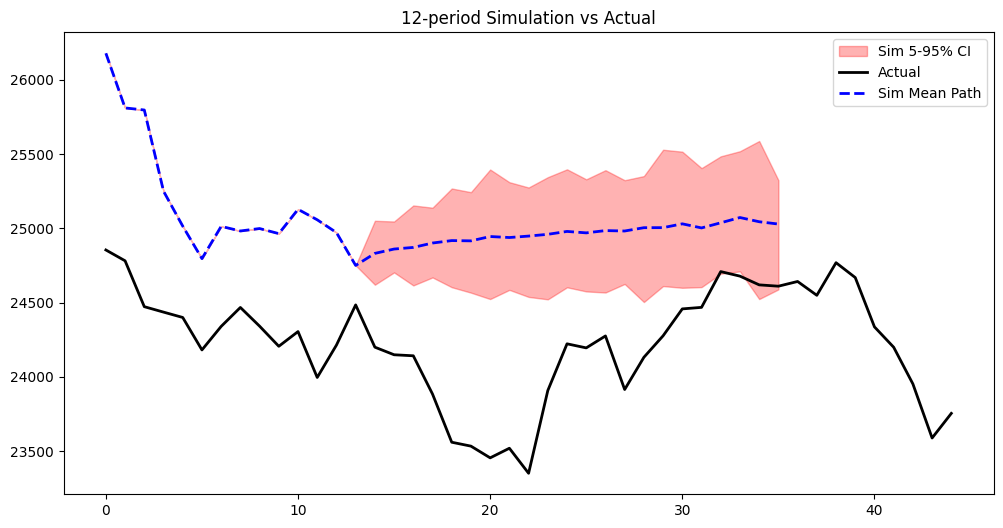

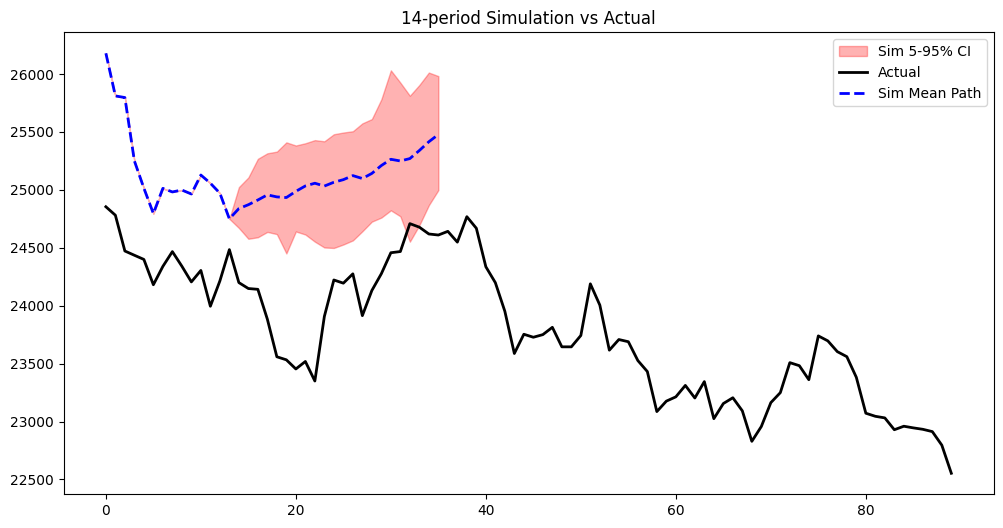

In [16]:
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

# --- 1. Full-horizon returns and vol for each path ---
def compute_sim_stats(sim_df):
    sim_ret = sim_df.apply(lambda x: (x.iloc[-1] / x.iloc[0]) - 1, axis=0)
    sim_vol = sim_df.pct_change().std()
    mean_path_ret = (sim_df.mean(axis=1).iloc[-1] / sim_df.mean(axis=1).iloc[0]) - 1
    mean_path_vol = sim_df.mean(axis=1).pct_change().std()
    return sim_ret, sim_vol, mean_path_ret, mean_path_vol

# 12-period
simRet12, simStd12, meanRet12, meanStd12 = compute_sim_stats(simulDf12)
# 14-period
simRet14, simStd14, meanRet14, meanStd14 = compute_sim_stats(simulDf14)

# --- 2. Actual realized returns and vol ---
actual_window_12 = closeMergedDf.loc[rebalDate:].iloc[:45].values.flatten()
actual_window_14 = closeMergedDf.loc[rebalDate:].iloc[:90].values.flatten()

actual_ret12 = (actual_window_12[-1] / actual_window_12[0]) - 1
actual_std12 = pd.Series(actual_window_12).pct_change().dropna().std()

actual_ret14 = (actual_window_14[-1] / actual_window_14[0]) - 1
actual_std14 = pd.Series(actual_window_14).pct_change().dropna().std()

# --- 3. Statistical similarity test (KS-test) ---
ks12_stat, ks12_p = ks_2samp(simulDf12.pct_change().values.flatten(),
                             pd.Series(actual_window_12).pct_change().dropna())
ks14_stat, ks14_p = ks_2samp(simulDf14.pct_change().values.flatten(),
                             pd.Series(actual_window_14).pct_change().dropna())

# --- 4. Save results into DataFrames ---
resultDf.loc[rebalDate] = [simRet12.mean(), simStd12.mean(), meanRet12, meanStd12]
resultDf['Actual_Ret'] = actual_ret12
resultDf['Actual_Std'] = actual_std12
resultDf14.loc[rebalDate] = [simRet14.mean(), simStd14.mean(), meanRet14, meanStd14]
resultDf14['Actual_Ret'] = actual_ret14
resultDf14['Actual_Std'] = actual_std14

# --- 5. Print summary ---
print("=== 12-period simulation ===")
print("Simulated mean return:", simRet12.mean())
print("Simulated mean vol:", simStd12.mean())
print("Mean path return:", meanRet12)
print("Mean path vol:", meanStd12)
print("Actual return:", actual_ret12)
print("Actual vol:", actual_std12)
print("KS-test p-value:", ks12_p)

print("\n=== 14-period simulation ===")
print("Simulated mean return:", simRet14.mean())
print("Simulated mean vol:", simStd14.mean())
print("Mean path return:", meanRet14)
print("Mean path vol:", meanStd14)
print("Actual return:", actual_ret14)
print("Actual vol:", actual_std14)
print("KS-test p-value:", ks14_p)

# --- 6. Visualize simulation CI vs actual ---
def plot_sim_vs_actual(sim_df, actual_prices, title):
    sim_lower = sim_df.quantile(0.05, axis=1)
    sim_upper = sim_df.quantile(0.95, axis=1)

    plt.figure(figsize=(12,6))
    plt.fill_between(range(len(sim_lower)), sim_lower, sim_upper, color='red', alpha=0.3, label='Sim 5-95% CI')
    plt.plot(actual_prices, color='black', lw=2, label='Actual')
    plt.plot(sim_df.mean(axis=1), color='blue', linestyle='--', lw=2, label='Sim Mean Path')
    plt.title(title)
    plt.legend()
    plt.show()

plot_sim_vs_actual(simulDf12, actual_window_12, "12-period Simulation vs Actual")
plot_sim_vs_actual(simulDf14, actual_window_14, "14-period Simulation vs Actual")


In [17]:
# Compute log returns
qReg = closeMergedDf.loc[reg.start.iloc[indexLists[1]]: reg.end.iloc[indexLists[1]]]
qRegRet = np.log(qReg).diff().dropna()
oRoi = closeMergedDf.loc[:rebalDate][-15:]

In [18]:
qRet12 = qRegRet.iloc[:45]
qRet14 = qRegRet.iloc[:90]
last_price = oRoi.iloc[-1, 0]

In [19]:
def simulate_figarch_prices(returns, last_price, horizon=45, rep=35, burn=500):
    """
    Fit FIGARCH(1,d,1) model with t-distribution, then simulate
    forward price paths using the volatility process' simulate method.
    """
    import numpy as np
    from arch import arch_model
    from scipy.stats import t

    # 1️⃣ Fit FIGARCH(1,d,1)
    figarch_mod = arch_model(returns, vol="FIGARCH", p=1, q=1, dist="t")
    figarch_fit = figarch_mod.fit(disp="off")

    # 2️⃣ Extract volatility parameters (in correct order)
    vol_names = figarch_mod.volatility.parameter_names()
    vol_params = np.array([figarch_fit.params[name] for name in vol_names])

    # 3️⃣ Extract degrees of freedom for t-distribution
    df_name = figarch_mod.distribution.parameter_names()[0]  # usually 'nu'
    nu = figarch_fit.params.get(df_name, 8.0)

    # 4️⃣ Simulate from the volatility process
    sim_prices = []
    for i in range(rep):
        # Use np.random.seed for reproducibility
        np.random.seed(i)

        resids, variance = figarch_mod.volatility.simulate(
            parameters=vol_params,
            nobs=horizon,
            burn=burn,
            rng=np.random.standard_normal  # ✅ callable, not Generator object
        )

        sigma = np.sqrt(variance)
        eps = t.rvs(df=nu, size=horizon)
        sim_returns = sigma * eps
        price_path = last_price * np.exp(np.cumsum(sim_returns))
        sim_prices.append(price_path)

    return sim_prices, figarch_fit

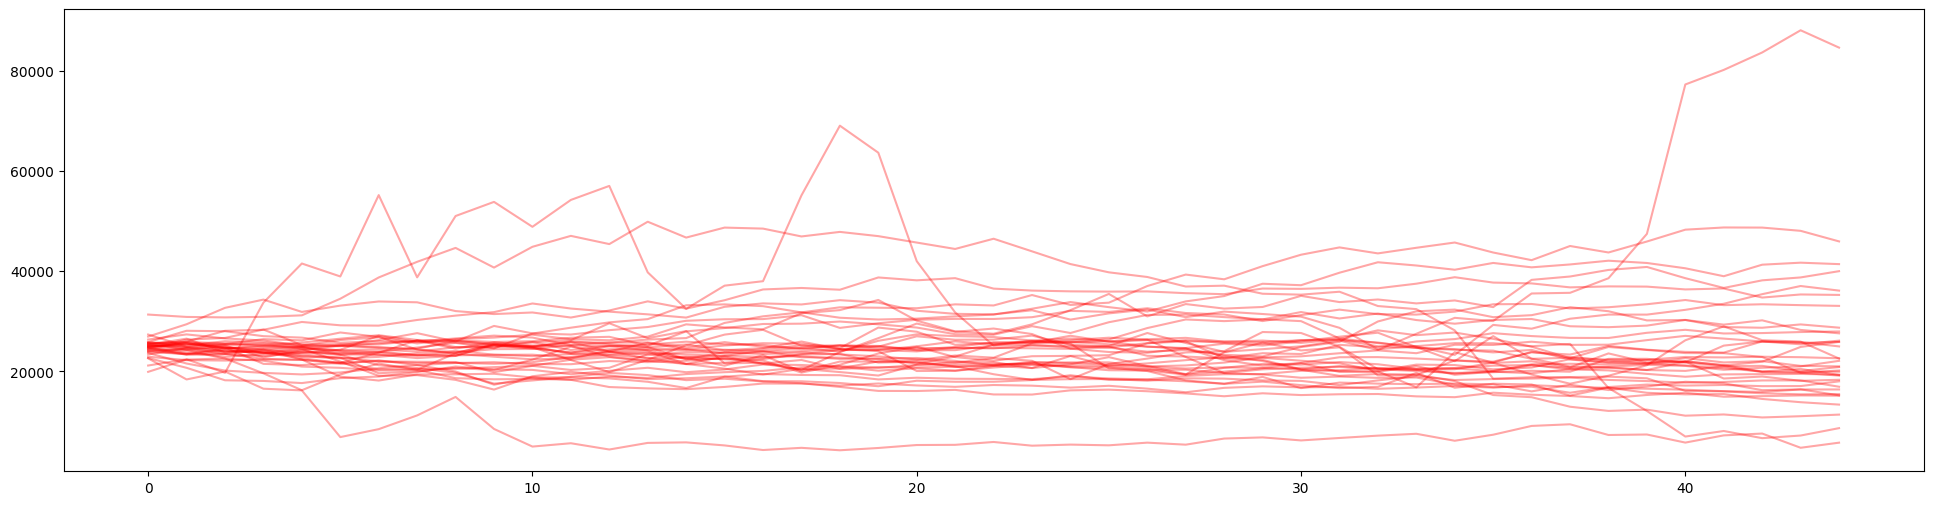

In [20]:
# ---- 2-month window (45 observations) -----------------
qRet12 = qRegRet.iloc[:45]
last_price = oRoi.iloc[-1, 0]

simPrice12, figarch_fit12 = simulate_figarch_prices(qRet12, last_price, horizon=45, rep=35)

# plot
fig, ax = plt.subplots(figsize=(24, 6))
pd.DataFrame(simPrice12).T.plot(ax=ax, color='r', alpha=0.35)
ax.get_legend().remove()

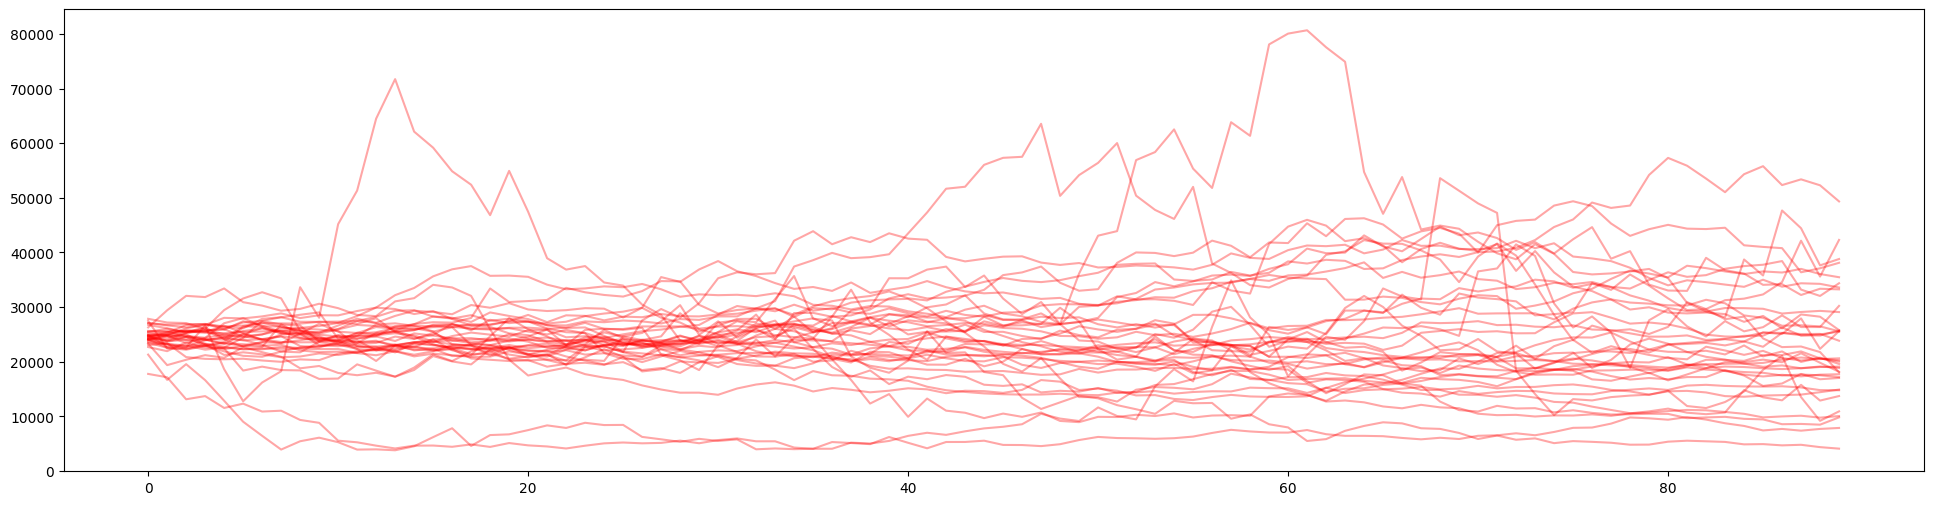

In [21]:
qRet14 = qRegRet.iloc[:90]
simPrice14, figarch_fit14 = simulate_figarch_prices(qRet14, last_price, horizon=90, rep=35)

fig, ax = plt.subplots(figsize=(24, 6))
pd.DataFrame(simPrice14).T.plot(ax=ax, color='r', alpha=0.35)
ax.get_legend().remove()

In [22]:
# Calculate metrics
simulDf12 = pd.DataFrame(simPrice12).T
simulDf14 = pd.DataFrame(simPrice14).T

# ----- 2-month (45-day) results -----
# resultDf.loc[rebalDate]['Ret_Avg'] = np.mean(simulDf12.apply(lambda x: (x[35] / x[13]) - 1))
# resultDf.loc[rebalDate]['Std_Avg'] = np.mean(simulDf12.apply(lambda x: np.std(np.diff(np.log(x)))))
# resultDf.loc[rebalDate]['Avg_Ret'] = (simulDf12.mean(1)[35] / simulDf12.mean(1)[0]) - 1
# resultDf.loc[rebalDate]['Avg_Std'] = np.std(np.diff(np.log(simulDf12.mean(1))))
# stDf.loc[rebalDate]['12'] = np.mean(np.std(np.diff(np.log(simulDf12), axis=0), axis=0))
resultDf.loc[rebalDate, 'Ret_Avg'] = np.mean(simulDf12.apply(lambda x: (x[35] / x[13]) - 1))
resultDf.loc[rebalDate, 'Std_Avg'] = np.mean(simulDf12.apply(lambda x: np.std(np.diff(np.log(x)))))
resultDf.loc[rebalDate, 'Avg_Ret'] = (simulDf12.mean(1)[35] / simulDf12.mean(1)[0]) - 1
resultDf.loc[rebalDate, 'Avg_Std'] = np.std(np.diff(np.log(simulDf12.mean(1))))
stDf.loc[rebalDate, '12'] = np.mean(np.std(np.diff(np.log(simulDf12), axis=0), axis=0))

# ----- 3-month (90-day) results -----
resultDf.loc[rebalDate, 'Ret_Avg_3M'] = np.mean(simulDf14.apply(lambda x: (x[70] / x[20]) - 1))
resultDf.loc[rebalDate, 'Std_Avg_3M'] = np.mean(simulDf14.apply(lambda x: np.std(np.diff(np.log(x)))))
resultDf.loc[rebalDate, 'Avg_Ret_3M'] = (simulDf14.mean(1)[70] / simulDf14.mean(1)[0]) - 1
resultDf.loc[rebalDate, 'Avg_Std_3M'] = np.std(np.diff(np.log(simulDf14.mean(1))))
stDf.loc[rebalDate, '14'] = np.mean(np.std(np.diff(np.log(simulDf14), axis=0), axis=0))

print(resultDf)
print(stDf)

             Ret_Avg   Std_Avg   Avg_Ret   Avg_Std  Actual_Ret  Actual_Std  \
2024-10-18 -0.001922  0.061658 -0.029319  0.012099   -0.044283    0.008619   

            Ret_Avg_3M  Std_Avg_3M  Avg_Ret_3M  Avg_Std_3M  
2024-10-18    0.214379    0.062798    0.049659    0.013579  
                  12        14
2024-10-18  0.061658  0.062798
